<a href="https://colab.research.google.com/github/Dentriciche/Project_SP/blob/main/baseline_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**/!\\ DISCLAIMER** The code of this notebook have been created with help of LLM, Sonnet 4.5

# Baseline Logistic Regression Model for South Park Character Classification

This notebook implements a baseline multiclass classification model to predict which South Park character spoke a given line of dialogue.

## Objectives:
- Load and preprocess the South Park dialogue dataset
- Build a parameterized logistic regression model (single-layer neural network)
- Train the model with proper handling of class imbalance
- Evaluate performance using comprehensive metrics

## Model Architecture:
The model is designed to be easily extensible to deeper networks by adding hidden layers.

## 1. Imports and Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import re
from typing import List

import sys
sys.path.append("../utils")

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import numpy as np
# Import evaluation utilities
from evaluate_models import (
    evaluate_model,
    print_evaluation_report,
    plot_confusion_matrix,
    get_per_class_metrics,
    print_classification_report,
    compare_models
)

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Configuration Parameters

These parameters control the dataset size and model behavior:

In [11]:
# Dataset configuration
K = 31  # Number of top characters to include


EMBEDDING_DIM = 64  # Original random embedding dimension

NUM_HIDDEN_LAYERS = 0  # 0 for logistic regression
HIDDEN_DIM = 128
DROPOUT_RATE = 0.5

# Training hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 25


print(f"Configuration:")
print(f"  Top K characters: {K}")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Hidden layers: {NUM_HIDDEN_LAYERS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Configuration:
  Top K characters: 31
  Embedding dimension: 64
  Hidden layers: 0
  Batch size: 64
  Learning rate: 0.001
  Epochs: 25


## 3. Data Loading

Load the South Park dialogue dataset from GitHub (seasons 1-19):

In [5]:
df = pd.read_parquet("../01 - Inputs/south_park_dialogues.parquet")

## 4. Train/Validation/Test Split

Loading the splited data:

In [7]:
train_data = pd.read_parquet('../01 - Inputs/train_data_labels_as_numbers.parquet')
val_data = pd.read_parquet('../01 - Inputs/val_data_labels_as_numbers.parquet')
test_data = pd.read_parquet('../01 - Inputs/test_data_labels_as_numbers.parquet')

In [8]:
train_texts = train_data['Line'].tolist()
train_labels = train_data['Character'].tolist()

val_texts = val_data['Line'].tolist()
val_labels = val_data['Character'].tolist()

test_texts = test_data['Line'].tolist()
test_labels = test_data['Character'].tolist()

## 5. Text Preprocessing and Vocabulary Building

**Important**: Build vocabulary only from training data to prevent data leakage!

In [9]:
from model_utils import preprocess_text, Vocabulary
import sys

# Preprocess all texts
print("Preprocessing texts...")
train_tokens = [preprocess_text(text) for text in tqdm(train_texts, desc="Train")]
val_tokens = [preprocess_text(text) for text in tqdm(val_texts, desc="Val")]
test_tokens = [preprocess_text(text) for text in tqdm(test_texts, desc="Test")]

# Build vocabulary
vocab = Vocabulary(min_freq=2)
vocab.build_vocab(train_tokens)

print(f"\nVocabulary size: {len(vocab):,}")
print(f"Special tokens: <pad>={vocab.word2idx['<pad>']}, <unk>={vocab.word2idx['<unk>']}, <cls>={vocab.word2idx['<cls>']}, <sep>={vocab.word2idx['<sep>']}")
print(f"\nMost common words:")
for word, count in vocab.word_counts.most_common(10):
    print(f"  {word}: {count}")

Preprocessing texts...


Test: 100%|██████████| 6036/6036 [00:00<00:00, 79249.54it/s]



Vocabulary size: 8,081
Special tokens: <pad>=0, <unk>=1, <cls>=2, <sep>=3

Most common words:
  you: 10603
  the: 9195
  i: 8060
  to: 7904
  a: 5939
  and: 5259
  it: 4271
  is: 3768
  we: 3744
  that: 3740


## 6. PyTorch Dataset and DataLoader

In [22]:
print("\nEncoding texts to indices...")
indexed_train_texts = [vocab.encode(text) for text in train_tokens]
indexed_val_texts = [vocab.encode(text) for text in val_tokens]
indexed_test_texts = [vocab.encode(text) for text in test_tokens]


Encoding texts to indices...


In [23]:
class DialogueDataset(Dataset):
    """
    PyTorch Dataset for South Park dialogue classification.
    """
    def __init__(self, texts: List[List[int]], labels: List[int]):
        self.texts = texts
        self.labels = labels
        self.classes = sorted(list(set(labels)))

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            'text': torch.tensor(self.texts[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = DialogueDataset(indexed_train_texts, train_labels)
val_dataset = DialogueDataset(indexed_val_texts, val_labels)
test_dataset = DialogueDataset(indexed_test_texts, test_labels)

print(f"Created datasets:")
print(f"  Train: {len(train_dataset):,} samples")
print(f"  Val:   {len(val_dataset):,} samples")
print(f"  Test:  {len(test_dataset):,} samples")

Created datasets:
  Train: 28,166 samples
  Val:   6,036 samples
  Test:  6,036 samples


In [24]:
def collate_batch(batch):
    """
    Collate function to handle variable-length sequences.
    Pads sequences to the maximum length in the batch.
    """
    labels = torch.tensor([item['label'] for item in batch])
    texts = [item['text'] for item in batch]

    # Find max length in this batch
    max_len = max(len(text) for text in texts)

    # Pad sequences
    padded_texts = torch.zeros(len(texts), max_len, dtype=torch.long)
    for i, text in enumerate(texts):
        padded_texts[i, :len(text)] = text

    return padded_texts.to(device), labels.to(device)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

print(f"\nCreated DataLoaders with batch size {BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


Created DataLoaders with batch size 64
  Train batches: 441
  Val batches:   95
  Test batches:  95


## 7. Model Architecture

For this character classification task, we are using:

1. **`nn.Embedding` (Trainable)**
   - Learns task-specific word representations
   - Best for capturing character-specific vocabulary and speaking patterns
   - Works well even with moderate dataset sizes
   - Simple to implement and train end-to-end

**For this baseline, we use trainable `nn.Embedding`** as it provides the best balance of simplicity and performance.

In [34]:
class CharacterClassifier(nn.Module):
    """
    Parameterized neural network for character classification.

    Can function as:
    - Logistic regression (num_hidden_layers=0)
    - Deep neural network (num_hidden_layers>0)

    Args:
        vocab_size: Size of vocabulary
        embedding_dim: Dimension of word embeddings
        num_classes: Number of output classes (characters)
        num_hidden_layers: Number of hidden layers (0 for logistic regression)
        hidden_dim: Dimension of hidden layers
        dropout_rate: Dropout rate for regularization
        pretrained_embeddings: Optional pre-trained embeddings (e.g., FastText)
        freeze_embeddings: Whether to freeze embedding weights
    """
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_classes: int,
        num_hidden_layers: int = 0,
        hidden_dim: int = 128,
        dropout_rate: float = 0.5,

    ):
        super().__init__()

        
        print(f"Using random embeddings: {vocab_size} x {embedding_dim}")
        self.embedding = nn.Embedding(
                vocab_size,
                embedding_dim,
                padding_idx=0
            )
           


        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Build hidden layers
        self.hidden_layers = nn.ModuleList()

        if num_hidden_layers == 0:
            # Logistic regression: direct embedding -> output
            self.fc_out = nn.Linear(embedding_dim, num_classes)
        else:
            # Deep network: embedding -> hidden layers -> output
            # First hidden layer
            self.hidden_layers.append(nn.Linear(embedding_dim, hidden_dim))

            # Additional hidden layers
            for _ in range(num_hidden_layers - 1):
                self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))

            # Output layer
            self.fc_out = nn.Linear(hidden_dim, num_classes)

        self.num_hidden_layers = num_hidden_layers

    def forward(self, text):
        """
        Forward pass.

        Args:
            text: Tensor of shape (batch_size, seq_len)

        Returns:
            Logits of shape (batch_size, num_classes)
        """
       
        # Embed tokens: (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(text)

        # Create mask for padding tokens
        mask = (text != 0).float().unsqueeze(-1)  

        # Apply mask to embeddings
        embedded = embedded * mask

        # Mean pooling: average over sequence length
        pooled = embedded.sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        # Apply dropout
        pooled = self.dropout(pooled)
        
        x = pooled
        for hidden_layer in self.hidden_layers:
            x = hidden_layer(x)
            x = torch.relu(x)
            x = self.dropout(x)

        # Output layer
        logits = self.fc_out(x)

        return logits

## 8. Initialize Model

In [35]:
# Initialize model
print("Initializing model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = CharacterClassifier(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_classes=K,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        dropout_rate=DROPOUT_RATE
    ).to(device)
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

print(f"\nModel architecture:")
print(model)

Initializing model...
Using random embeddings: 8081 x 64

Model Statistics:
  Total parameters: 519,199
  Trainable parameters: 519,199

Model architecture:
CharacterClassifier(
  (embedding): Embedding(8081, 64, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (hidden_layers): ModuleList()
  (fc_out): Linear(in_features=64, out_features=31, bias=True)
)


## 9. Handle Class Imbalance with Class Weights

Calculate class weights to handle imbalanced dataset:

In [36]:
from train_utils import compute_balanced_class_weights

class_weights = compute_balanced_class_weights(train_labels, len(set(train_labels)), device)

print("Class weights computed")
print(f"Class weights: {class_weights}")
print(f"Weight range: {class_weights.min():.3f} - {class_weights.max():.3f}")

Class weights computed
Class weights: tensor([0.1364, 0.1860, 0.1983, 0.5028, 0.5031, 1.2196, 1.4968, 1.5143, 1.7273,
        1.9168, 2.0236, 2.0372, 2.2490, 2.3119, 2.3661, 2.3723, 3.1880, 3.4945,
        3.7390, 4.2064, 4.2260, 4.3061, 4.4979, 4.6356, 4.6594, 4.6834, 5.0198,
        5.4082, 5.9384, 6.1391, 6.2232])
Weight range: 0.136 - 6.223


## 10. Training Setup

In [37]:
print(f"Training setup:")
print(f"  Loss function: CrossEntropyLoss (with class weights)")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Epochs: {NUM_EPOCHS}")

Training setup:
  Loss function: CrossEntropyLoss (with class weights)
  Optimizer: Adam (lr=0.001)
  Epochs: 25


## 11. Training Loop

In [ ]:
import time
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, patience=7):

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_f1': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    

    print("\nStarting training...\n")
    print("="*70)
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for text, labels in train_pbar:
            # Forward pass
            optimizer.zero_grad()
            outputs = model(text)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for text, labels in val_loader:
                outputs = model(text)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)

        # Calculate metrics
        val_accuracy = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['val_f1'].append(val_f1)

        # Print epoch summary
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val Acc:    {val_accuracy:.4f}")
        print(f"  Val F1:     {val_f1:.4f}")
        print("-"*70)

    model.load_state_dict(best_model_state)
    elapsed = time.time() - start_time
    
    print("\nTraining complete!")
    print(f"Training completed in {elapsed/60:.2f} minutes")
    
    return {'model': model, 'history': history, 'best_val_loss': best_val_loss, 'time': elapsed}
    print("="*70)

## 15. Plot Training History

In [39]:
from focal_loss import FocalLoss

loss_types = ['cross_entropy_label_smoothing', 'cross_entropy', 'focal_loss']
components = {}
models = {}

for loss_type in loss_types:
    models[loss_type] = CharacterClassifier(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        num_classes=K,
        num_hidden_layers=NUM_HIDDEN_LAYERS,
        hidden_dim=HIDDEN_DIM,
        dropout_rate=DROPOUT_RATE
    ).to(device)
    
    optimizer = optim.Adam(models[loss_type].parameters(), lr=LEARNING_RATE)

    if loss_type == 'cross_entropy_label_smoothing':
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    elif loss_type == 'cross_entropy':
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    elif loss_type == 'focal_loss':
        criterion = FocalLoss(
            alpha=class_weights,
            gamma=2.0,
            task_type="multi-class",
            num_classes=K
        )
        
    components[loss_type] = {'model': models[loss_type], 'optimizer': optimizer, 'criterion': criterion}

Using random embeddings: 8081 x 64
Using random embeddings: 8081 x 64
Using random embeddings: 8081 x 64


In [40]:
results = {}

for loss_type in loss_types:
    print(f"\n{'='*80}")
    print(f"Training with {loss_type} loss...")
    print(f"{'='*80}")
    
    comp = components[loss_type]
    
    results[loss_type] = train_model(
        comp['model'], 
        train_loader,
        val_loader,
        NUM_EPOCHS,
        comp['optimizer'],
        comp['criterion']
    )
    
    print(f"\n✓ {loss_type} complete!")


Training with cross_entropy_label_smoothing loss...

Starting training...



Epoch 1/25 [Train]: 100%|██████████| 441/441 [00:06<00:00, 70.93it/s, loss=5.3284]


Epoch 1/25:
  Train Loss: 4.2005
  Val Loss:   4.1332
  Val Acc:    0.0161
  Val F1:     0.0201
----------------------------------------------------------------------


Epoch 2/25 [Train]: 100%|██████████| 441/441 [00:06<00:00, 65.39it/s, loss=4.3777]


Epoch 2/25:
  Train Loss: 4.1360
  Val Loss:   4.1035
  Val Acc:    0.0249
  Val F1:     0.0321
----------------------------------------------------------------------


...

Epoch 23/25:
  Train Loss: 0.0737
  Val Loss:   0.0874
  Val Acc:    0.1634
  Val F1:     0.1520
----------------------------------------------------------------------


Epoch 24/25 [Train]: 100%|██████████| 441/441 [00:10<00:00, 42.53it/s, loss=0.0448]


Epoch 24/25:
  Train Loss: 0.0728
  Val Loss:   0.0871
  Val Acc:    0.1660
  Val F1:     0.1545
----------------------------------------------------------------------


Epoch 25/25 [Train]: 100%|██████████| 441/441 [00:11<00:00, 38.09it/s, loss=0.0197]


Epoch 25/25:
  Train Loss: 0.0718
  Val Loss:   0.0869
  Val Acc:    0.1730
  Val F1:     0.1591
----------------------------------------------------------------------

Training complete!
Training completed in 5.28 minutes

✓ focal_loss complete!


## 16. Evaluate on Test Set

Use the evaluation utilities from `evaluate_models.py`:

In [41]:
import pickle
label_to_char = pickle.load(open('../01 - Inputs/label_to_char.pkl', 'rb'))
char_to_label = pickle.load(open('../01 - Inputs/char_to_label.pkl', 'rb'))

In [44]:
y_true = [label_to_char[i] for i in test_labels]


Testing with cross_entropy_label_smoothing loss...


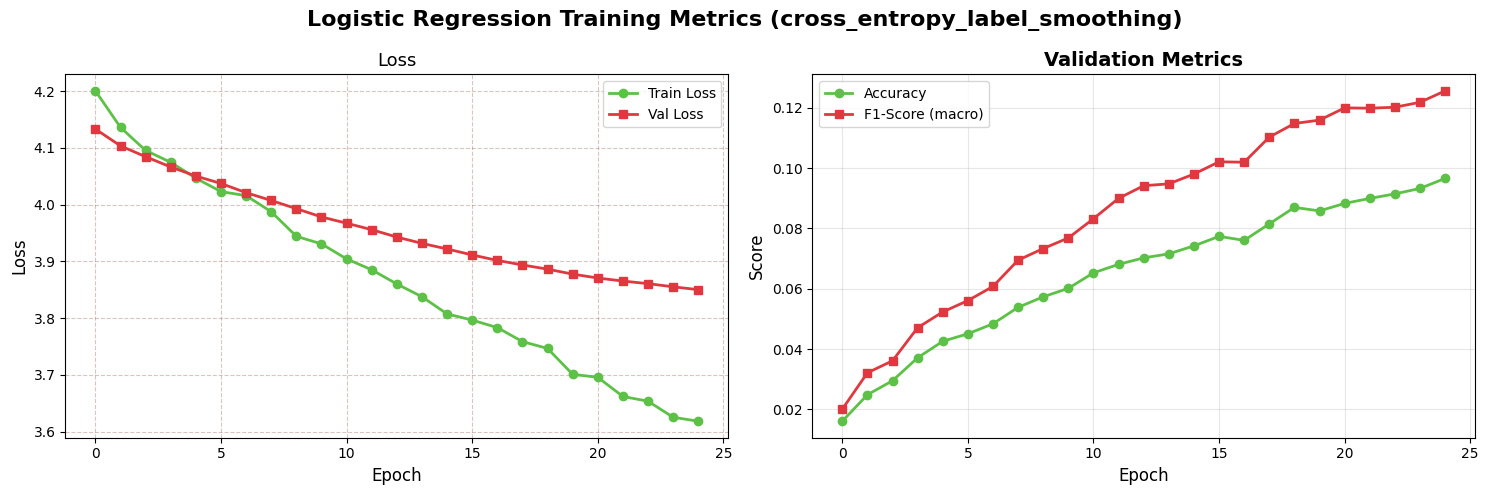

c:\Users\sarae\Desktop\DSTI-DEEP-LEARNING-PROJECT\.conda\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\sarae\Desktop\DSTI-DEEP-LEARNING-PROJECT\.conda\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


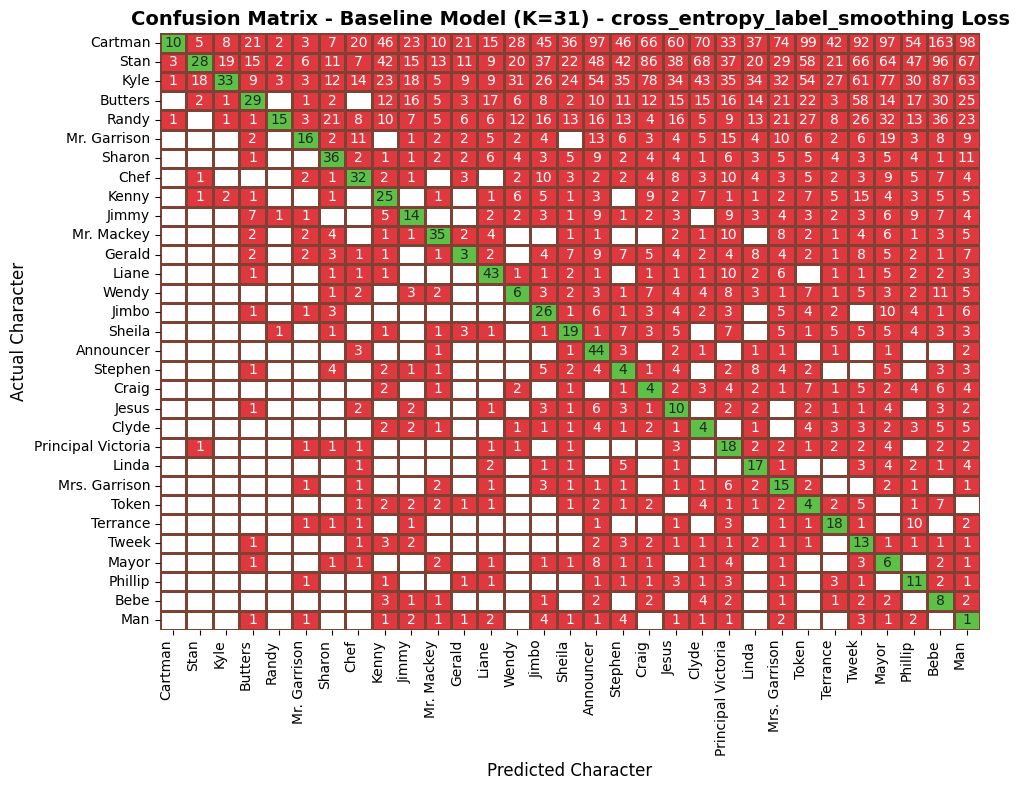

Metrics for cross_entropy_label_smoothing loss:
Accuracy:  0.0906
Precision: 0.1789
Recall:    0.2143
F1-Score:  0.1185

Testing with cross_entropy loss...


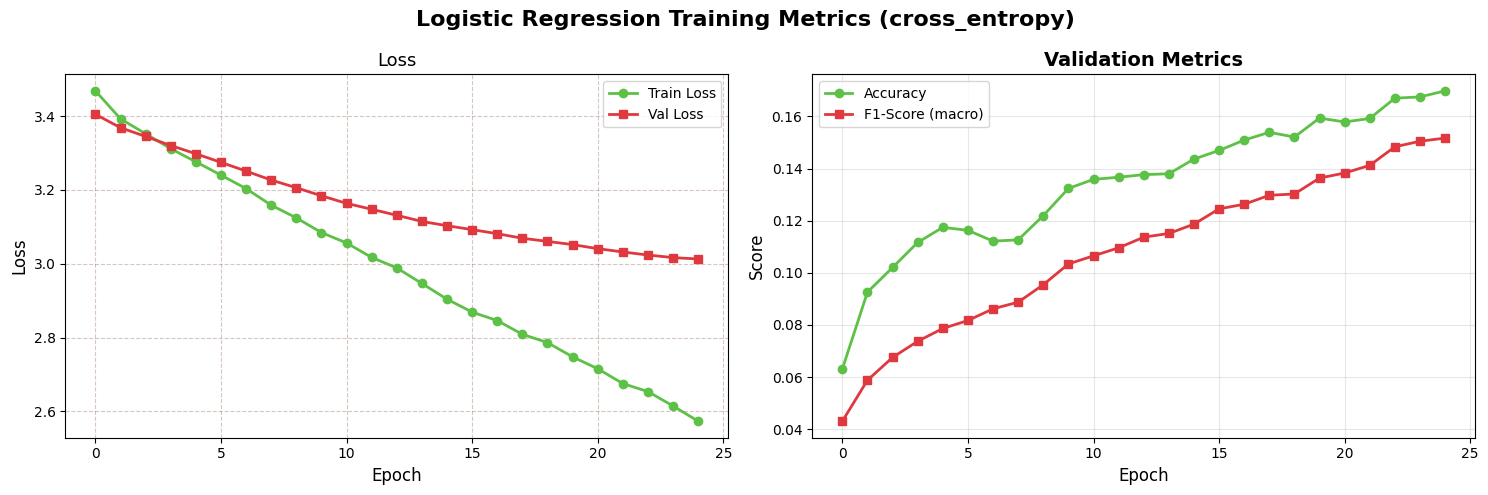

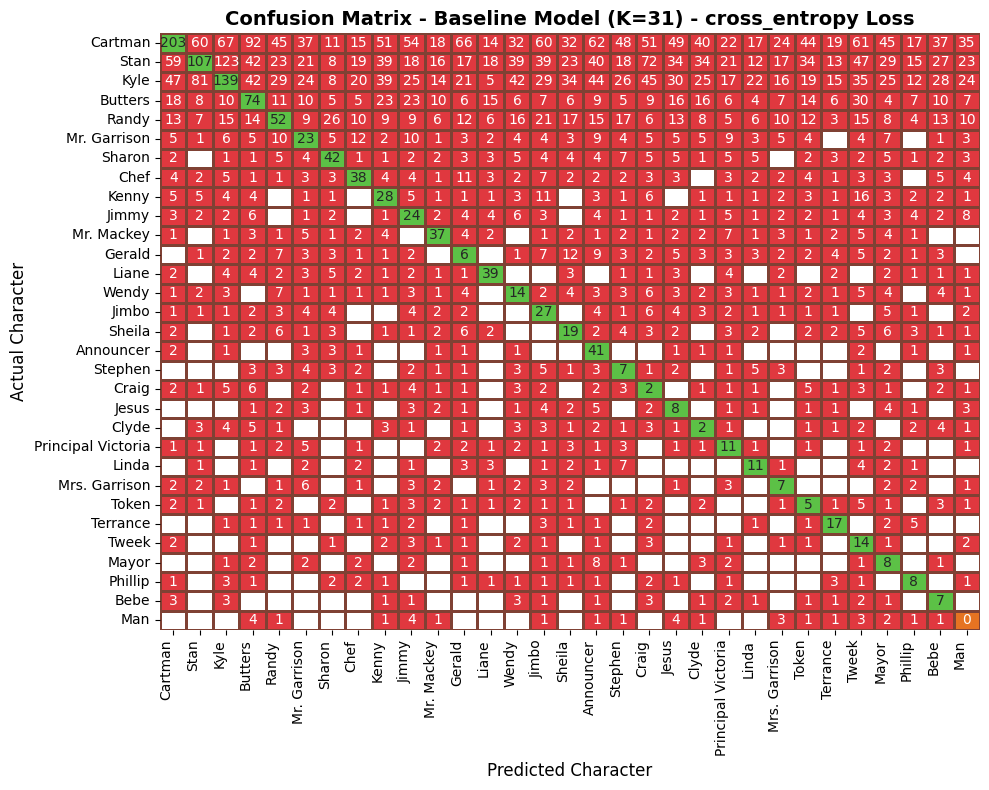

Metrics for cross_entropy loss:
Accuracy:  0.1690
Precision: 0.1462
Recall:    0.2217
F1-Score:  0.1485

Testing with focal_loss loss...


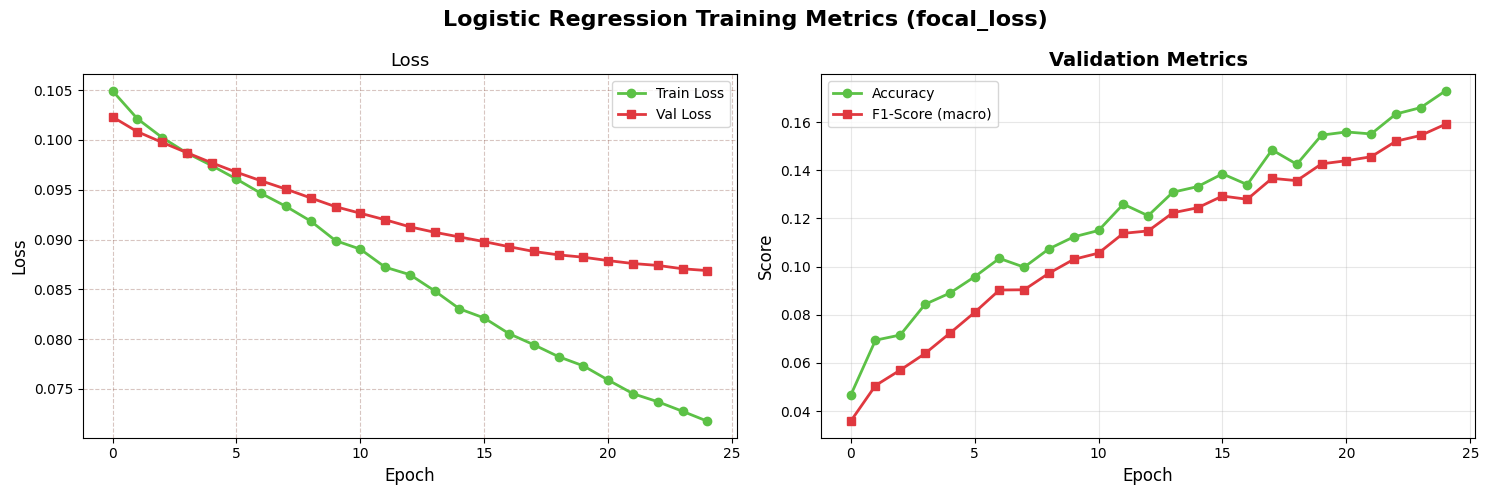

c:\Users\sarae\Desktop\DSTI-DEEP-LEARNING-PROJECT\.conda\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\sarae\Desktop\DSTI-DEEP-LEARNING-PROJECT\.conda\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


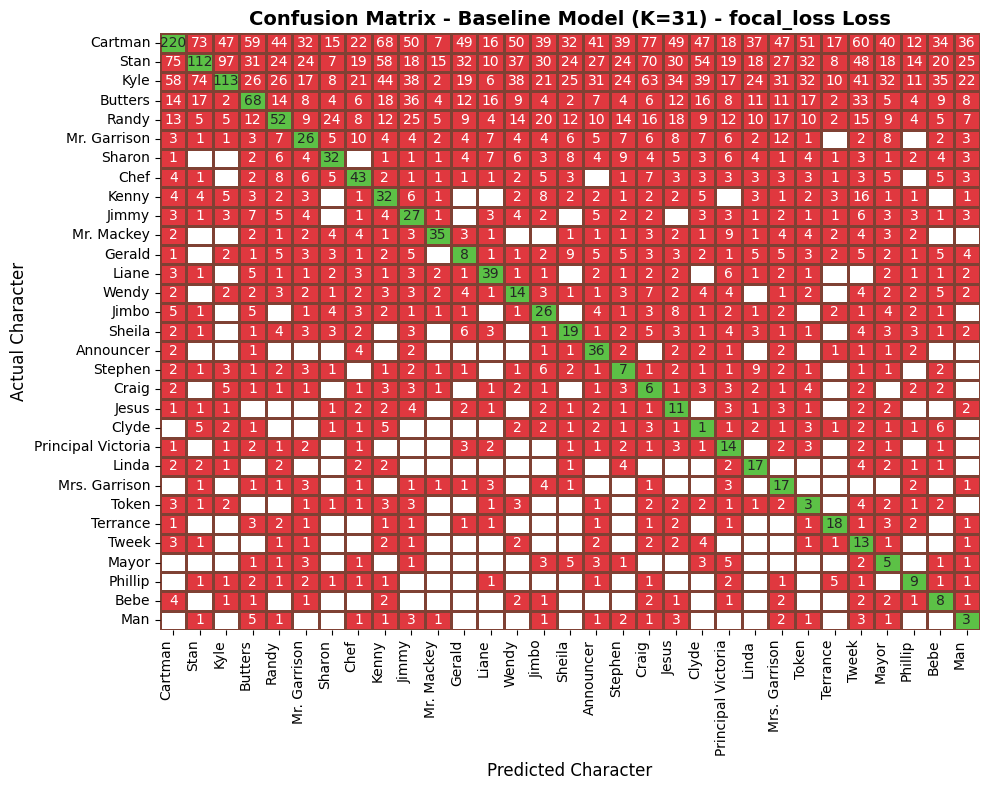

Metrics for focal_loss loss:
Accuracy:  0.1713
Precision: 0.1581
Recall:    0.2383
F1-Score:  0.1590

Baseline Logistic Regression - Best Model Evaluation Results
Accuracy:  0.1713
Precision: 0.1581 (macro)
Recall:    0.2383 (macro)
F1-Score:  0.1590 (macro)



In [53]:
from evaluate_models import SP_GREEN, SP_RED,  SP_BROWN

def plot_training_history(result, loss_type):
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    fig.suptitle(f"Logistic Regression Training Metrics ({loss_type})", fontsize=16, fontweight="bold")
    axes[0].plot(result['history']['train_loss'], label='Train Loss', marker='o', color=SP_GREEN, linewidth=2)
    axes[0].plot(result['history']['val_loss'], label='Val Loss', marker='s', color=SP_RED, linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss', fontsize=13)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, color=SP_BROWN, linestyle='--')

    axes[1].plot(result['history']['val_accuracy'], label='Accuracy', marker='o', color=SP_GREEN, linewidth=2)
    axes[1].plot(result['history']['val_f1'], label='F1-Score (macro)', marker='s', color=SP_RED, linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Validation Metrics', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'baseline_logistic_regression_k{K}_{loss_type}_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    

best_val_loss = float('inf')
best_model = None
test_metrics_df = []

for loss_type, result in results.items():
    print(f"\n{'='*80}")
    print("="*80)
    print(f"Testing with {loss_type} loss...")
    print("="*80)
    model = result['model']
        
    test_metrics, test_preds, test_true = evaluate_model(
            model=model,
            data_loader=test_loader,
            device=device,
            class_names=[label_to_char[i] for i in range(K)],
            return_predictions=True
        )
    y_pred = [label_to_char[i] for i in test_preds]
    
    if best_val_loss > result['best_val_loss']:
            best_val_loss = result['best_val_loss']
            best_model = model
            best_test_metrics = test_metrics
            best_test_preds = test_preds
            best_test_true = test_true
            best_loss_type = loss_type
    
    plot_training_history(result, loss_type)
    
    plot_confusion_matrix(
        y_true,
        y_pred,
        save_path=f'baseline_logistic_regression_k{K}_{loss_type}_confusion_matrix.png',
        title=f"Confusion Matrix - Baseline Model (K={K}) - {loss_type} Loss"
    )
    
    test_metrics_df.append(pd.DataFrame([test_metrics], index=[f'Baseline Logistic Regression {loss_type}']))
    
    print("="*80)
    print(f"Metrics for {loss_type} loss:")
    print("="*80)
    print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall:    {test_metrics['recall']:.4f}")
    print(f"F1-Score:  {test_metrics['f1_score']:.4f}")
    
test_metrics_df = pd.concat(test_metrics_df)

test_metrics_best, test_preds_best, test_true_best = evaluate_model(
    model=best_model,
    data_loader=test_loader,
    device=device,
    class_names=[label_to_char[i] for i in range(K)],
    return_predictions=True
)
   
 
print_evaluation_report(test_metrics_best, model_name="Baseline Logistic Regression - Best Model")
    

## 18. Per-Class Performance

In [51]:
best_loss_type

'focal_loss'

In [50]:
# Get per-class metrics
per_class_df = get_per_class_metrics(
    y_true=test_true,
    y_pred=test_preds_best,
    class_names=[label_to_char[i] for i in range(K)]
)

print("\nPer-Class Performance:")
print("="*70)
print(per_class_df.to_string(index=False))
print("="*70)


Per-Class Performance:
             Class  Precision   Recall  F1-Score  Support
           Cartman   0.510441 0.154062  0.236686     1428
              Stan   0.367213 0.106972  0.165680     1047
              Kyle   0.384354 0.115071  0.177116      982
           Butters   0.274194 0.175711  0.214173      387
             Randy   0.241860 0.134367  0.172757      387
      Mr. Garrison   0.159509 0.162500  0.160991      160
            Sharon   0.262295 0.246154  0.253968      130
              Chef   0.265432 0.335938  0.296552      128
             Kenny   0.116364 0.283186  0.164948      113
             Jimmy   0.110204 0.267327  0.156069      101
        Mr. Mackey   0.421687 0.364583  0.391061       96
            Gerald   0.049689 0.084211  0.062500       95
             Liane   0.312000 0.448276  0.367925       87
             Wendy   0.071795 0.166667  0.100358       84
             Jimbo   0.136842 0.313253  0.190476       83
            Sheila   0.121019 0.231707  0.158996

## 19. Save Model (Optional)

In [52]:

model = results[best_loss_type]['model']
history = results[best_loss_type]['history']
checkpoint = {
    'model_type': 'Logistic Regression' if NUM_HIDDEN_LAYERS == 0 else f'Deep Network ({NUM_HIDDEN_LAYERS} layers)',
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'K': K,
        'vocab_size': len(vocab),
        'embedding_dim': EMBEDDING_DIM,
        'num_hidden_layers': NUM_HIDDEN_LAYERS,
        'hidden_dim': HIDDEN_DIM,
        'dropout_rate': DROPOUT_RATE,
        'loss_type': best_loss_type
    },
    'char_to_label': char_to_label,
    'label_to_char': label_to_char,
    'vocab': vocab.word2idx,
    'test_metrics': test_metrics,
    'history': history,
    # 'training_time': elapsed
}

filename = f'baseline_logistic_k{K}.pt' 
torch.save(checkpoint, filename)
print(f"Model saved to: {filename}")

Model saved to: baseline_logistic_k31.pt
